<a href="https://colab.research.google.com/github/joeyhattan27/python-for-ai/blob/main/gaussian_processes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib ipykernel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 43.9 MB/s eta 0:00:00


In [10]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(100)

locations = np.arange(1, 51)

true_oil = (
    30
    + 45 * np.exp(-0.5 * ((15 - locations) / 5) ** 2)
    + 20 * np.exp(-0.5 * ((35 - locations) / 7) ** 2)
)

noise = np.random.normal(0, 5, size=len(locations))
observed_oil = true_oil + noise
observed_oil

array([26.51858629, 32.38913504, 35.40923339, 33.37148496, 38.54544376,
       40.19473893, 43.07133695, 44.22565122, 51.45030883, 57.96536889,
       61.58767197, 68.76558439, 70.22451525, 76.37323791, 77.0193997 ,
       74.35052222, 70.94519548, 71.20935405, 63.04876064, 56.51146207,
       58.65801133, 54.30829198, 46.48330665, 42.61782825, 43.76034024,
       45.09547304, 44.76256761, 47.06663897, 43.9286406 , 46.13584346,
       47.81223638, 44.77603124, 47.37824954, 51.8710222 , 51.89120772,
       48.66373743, 52.17697796, 44.01968334, 43.59676554, 42.41582999,
       42.49034905, 40.4602048 , 40.4272958 , 37.21895015, 40.45832664,
       31.48573728, 32.14305079, 34.45904899, 28.67275941, 35.69016266])

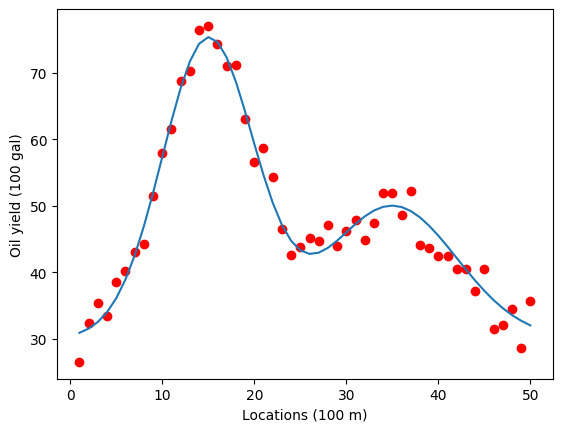

In [11]:
plt.scatter(locations, observed_oil, color="red")
plt.plot(locations, true_oil)
plt.xlabel("Locations (100 m)")
plt.ylabel("Oil yield (100 gal)")
plt.show()

In [48]:
def rbf_kernel(x1, x2, length_scale, sigma):
  x1 = x1.reshape(-1, 1)
  x2 = x2.reshape(1, -1)
  squared_distance = (x1 - x2) ** 2

  return sigma**2 * np.exp(-squared_distance/(2 * length_scale**2))

K = rbf_kernel(locations, locations, 6, 15)


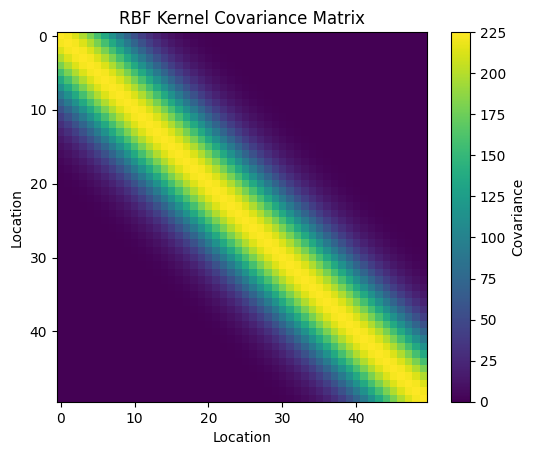

In [49]:
plt.imshow(K)
plt.colorbar(label="Covariance")
plt.xlabel("Location")
plt.ylabel("Location")
plt.title("RBF Kernel Covariance Matrix")
plt.show()

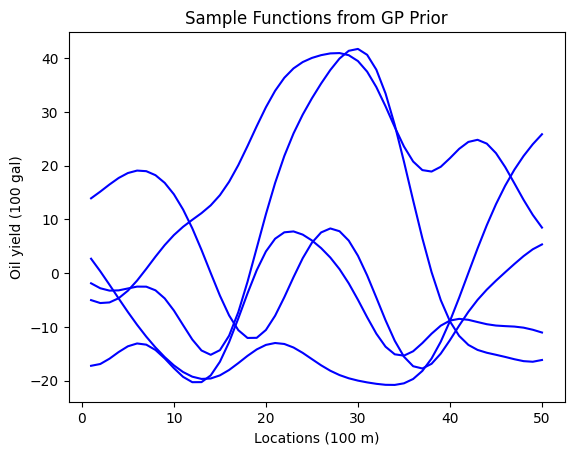

In [52]:
mean_vector = np.zeros(len(locations))
cov_matrix = K
sample_functions = np.random.multivariate_normal(mean_vector, cov_matrix, size=5)

for sample_function in sample_functions:
  plt.plot(locations, sample_function, color="blue")

plt.xlabel("Locations (100 m)")
plt.ylabel("Oil yield (100 gal)")
plt.title("Sample Functions from GP Prior")
plt.show()

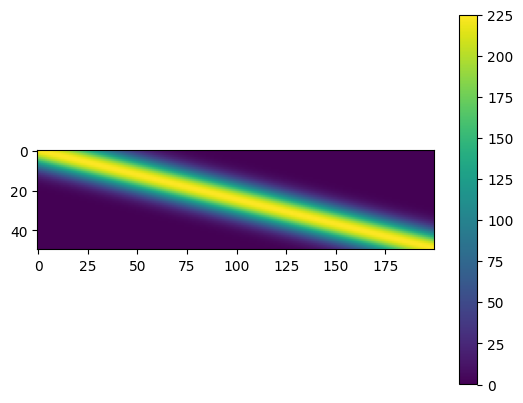

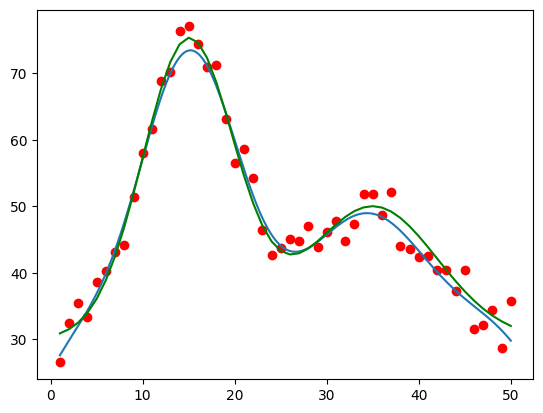

In [59]:
#add noise to the covariance matrix for obsereved points (doesnt force function
# through observed point)
sigma_noise = 6
K_y = K + sigma_noise**2 * np.eye(len(locations))

X_train = locations
y_train = observed_oil
X_test = np.linspace(1, 50, 200)

K_cross = rbf_kernel(X_train, X_test, 6, 15)
plt.imshow(K_cross)
plt.colorbar()
plt.show()

alpha = np.linalg.solve(K_y, y_train)

y_test = K_cross.T @ alpha
y_test


plt.plot(X_test, y_test)
plt.scatter(X_train, y_train, color="red")
plt.plot(X_train, true_oil, color = "green")